In [614]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer
import ast # string olarak saklanan listeleri gerçek listelere dönüştürmek için

from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 

In [615]:
data = pd.read_csv('/Users/oguzhanerbil/Documents/Repolarım/food-health-predictor/data/data.csv')

In [616]:
config = {
    'alerjenler': 10,          
    'eser_miktarlar': 50,  
    'kategori_listesi': 50,   
    'etiketler_listesi': 50,
}

def convert_to_list(x):
    if pd.isna(x): return []
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return x

for col, min_count in config.items():
    if col in data.columns:
        data[col] = data[col].apply(convert_to_list)
        counts = data[col].explode().value_counts()
        valid_elements = counts[counts >= min_count].index.tolist()
        data[col] = data[col].apply(lambda x: [i for i in x if i in valid_elements])
        mlb = MultiLabelBinarizer()
        encoded = mlb.fit_transform(data[col])
        col_names = [f"{col}_{str(c).strip().replace(' ', '_')}" for c in mlb.classes_]
        encoded_df = pd.DataFrame(encoded, columns=col_names, index=data.index)
        data = pd.concat([data, encoded_df], axis=1)
        print(f"Bitti! {len(col_names)} adet yeni kolon eklendi. {col}")

Bitti! 17 adet yeni kolon eklendi. alerjenler
Bitti! 14 adet yeni kolon eklendi. eser_miktarlar
Bitti! 137 adet yeni kolon eklendi. kategori_listesi
Bitti! 62 adet yeni kolon eklendi. etiketler_listesi


In [617]:

data['markalar'] = data['markalar'].astype(str).str.lower().str.strip()
marka_counts = data['markalar'].value_counts()

valid_markalar = marka_counts[marka_counts >= 50].index.tolist()

for marka in valid_markalar:
    clean_marka_name = marka.replace(' ', '_').replace('.', '').replace('-', '_')
    data[f'marka_{clean_marka_name}'] = (data['markalar'] == marka).astype(int)

print(f"Bitti! 50'den fazla ürünü olan {len(valid_markalar)} marka için yeni kolonlar eklendi.")

Bitti! 50'den fazla ürünü olan 15 marka için yeni kolonlar eklendi.


In [618]:
def standardize_unit(row):
    u = str(row['birim']).lower().strip()
    miktar = row['miktar']
    
    # Sıvılar -> ML cinsinden standartlaştırma
    if u in ['l', 'litre', 'litro', 'litri', 'liter', 'litros', 'litres', 'litra']:
        return miktar * 1000  
    if u == 'cl':
        return miktar * 10  
    if u in ['ml', 'fl']:
        return miktar        
        

    if u == 'kg':
        return miktar * 1000
    if u in ['oz', 'ounces']:
        return miktar * 28.35 
    if u in ['lb', 'lbs', 'pounds']:
        return miktar * 453.59 
    if u in ['g', 'gram', 'grams', 'gm']:
        return miktar        
        
    return miktar

data['miktar_standart'] = data.apply(standardize_unit, axis=1)

def categorize_unit(u):
    u = str(u).lower().strip()
    if u in ['l', 'cl', 'ml', 'litre', 'fl']: return 2 # Sıvı
    if u in ['g', 'kg', 'gram', 'lb', 'oz']: return 1  # Katı
    return 0 # Belirsiz

data['birim_tipi'] = data['birim'].apply(categorize_unit)

vegan_map = {'yes': 1, 'maybe': 0.5, 'no': 0}
data['vegan_durumu'] = data['vegan_durumu'].map(vegan_map).fillna(0)

# 3. Yeşil Skor Mapping
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5}
data['yesil_skor_notu'] = data['yesil_skor_notu'].map(grade_map).fillna(2) # Bilinmiyorsa orta değer C(2)

# 4. Boolean (True/False) Dönüşümü
data['vejetaryen'] = data['vejetaryen'].astype(float).fillna(0)
data['palmiye_yagi_icermez'] = data['palmiye_yagi_icermez'].astype(float).fillna(0)

In [619]:
# Harfleri sayıya çevirelim
mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
data['nutriscore_notu'] = data['nutriscore_notu'].map(mapping)

# Eğer Nutriscore'u boş olan satırlar varsa onları da silelim:
data = data.dropna(subset=['nutriscore_notu'])

In [620]:
data.drop(columns=["eser_miktarlar","kategori_listesi","alerjenler","etiketler_listesi","markalar","birim"], inplace=True)

In [621]:
data.head()

,barkod,miktar,icerik_sayisi,nutriscore_notu,nova_grubu,yesil_skor_notu,palmiye_yagi_icermez,vejetaryen,vegan_durumu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde,alerjenler_Celery,alerjenler_Cereals-with-gluten,alerjenler_Crustaceans,alerjenler_Eggs,alerjenler_Fish,alerjenler_Gluten,alerjenler_Lupin,alerjenler_Milk,alerjenler_Molluscs,alerjenler_Mustard,alerjenler_Nuts,alerjenler_Peanuts,alerjenler_Sesame_seeds,alerjenler_Soybeans,alerjenler_Sulphur_dioxide_and_sulphites,alerjenler_es:avena,alerjenler_fr:avoine,eser_miktarlar_Celery,eser_miktarlar_Crustaceans,eser_miktarlar_Eggs,eser_miktarlar_Fish,eser_miktarlar_Gluten,eser_miktarlar_Lupin,eser_miktarlar_Milk,eser_miktarlar_Molluscs,eser_miktarlar_Mustard,eser_miktarlar_Nuts,eser_miktarlar_Peanuts,eser_miktarlar_Sesame_seeds,eser_miktarlar_Soybeans,eser_miktarlar_Sulphur_dioxide_and_sulphites,kategori_listesi_Almonds,kategori_listesi_Appetizers,kategori_listesi_Apple_compotes,kategori_listesi_Beverages,kategori_listesi_Beverages_and_beverages_preparations,kategori_listesi_Breaded_fish,kategori_listesi_Breaded_products,kategori_listesi_Breads,kategori_listesi_Breakfast_cereals,kategori_listesi_Breakfasts,kategori_listesi_Canned_common_beans,kategori_listesi_Canned_fishes,kategori_listesi_Canned_foods,kategori_listesi_Canned_legumes,kategori_listesi_Canned_meals,kategori_listesi_Canned_plant-based_foods,kategori_listesi_Canned_tomatoes,kategori_listesi_Canned_tunas,kategori_listesi_Canned_vegetables,kategori_listesi_Carbonated_drinks,kategori_listesi_Carbonated_waters,kategori_listesi_Cereal_flakes,kategori_listesi_Cereal_grains,kategori_listesi_Cereal_pastas,kategori_listesi_Cereals_and_potatoes,kategori_listesi_Cereals_and_their_products,kategori_listesi_Cereals_with_fruits,kategori_listesi_Cheeses,kategori_listesi_Chicken_and_its_products,kategori_listesi_Chicken_eggs,kategori_listesi_Compotes,kategori_listesi_Condiments,kategori_listesi_Dairies,kategori_listesi_Dairy_desserts,kategori_listesi_Dairy_substitutes,kategori_listesi_Desserts,kategori_listesi_Dry_durum_wheat_pasta,kategori_listesi_Dry_pastas,kategori_listesi_Durum_wheat_pasta,kategori_listesi_Eggs,kategori_listesi_Extruded_cereals,kategori_listesi_Farming_products,kategori_listesi_Fats,kategori_listesi_Fatty_fishes,kategori_listesi_Fermented_dairy_desserts,kategori_listesi_Fermented_dairy_desserts_with_fruits,kategori_listesi_Fermented_foods,kategori_listesi_Fermented_milk_products,kategori_listesi_Fish_fillets,kategori_listesi_Fish_preparations,kategori_listesi_Fishes,kategori_listesi_Fishes_and_their_products,kategori_listesi_Flakes,kategori_listesi_Flours,kategori_listesi_Free-range_chicken_eggs,kategori_listesi_Fresh_foods,kategori_listesi_Fromages_blancs_-_petit_suisses_and_skyr,kategori_listesi_Frozen_foods,kategori_listesi_Frozen_plant-based_foods,kategori_listesi_Frozen_ready-made_meals,kategori_listesi_Frozen_vegetables,kategori_listesi_Fruits,kategori_listesi_Fruits_and_vegetables_based_foods,kategori_listesi_Fruits_based_foods,kategori_listesi_Greek-style_yogurts,kategori_listesi_Groceries,kategori_listesi_Legume_butters,kategori_listesi_Legume_seeds,kategori_listesi_Legumes,kategori_listesi_Legumes_and_their_products,kategori_listesi_Lentils,kategori_listesi_Meals,kategori_listesi_Meals_with_meat,kategori_listesi_Meat_alternatives,kategori_listesi_Meat_analogues,kategori_listesi_Meats,kategori_listesi_Meats_and_their_products,kategori_listesi_Milks,kategori_listesi_Milks_(liquid_and_powder),kategori_listesi_Mineral_waters,kategori_listesi_Mueslis,kategori_listesi_Natural_mineral_waters,kategori_listesi_Non-dairy_desserts,kategori_listesi_Nut_butters,kategori_listesi_Nuts,kategori_listesi_Nuts_and_their_products,kategori_listesi_Oilseed_purees,kategori_listesi_Olive_oils,kategori_listesi_Olive_tree_products,kategori_listesi_Pastas,kategori_listesi_Peanut_butters,kategori_listesi_Plain_fermented_dairy_desserts,kategori_listesi_Plain_yo

In [622]:
data.isnull().mean() * 100

barkod                                                        0.000000
miktar                                                       10.931459
icerik_sayisi                                                 6.168717
nutriscore_notu                                               0.000000
nova_grubu                                                   11.054482
yesil_skor_notu                                               0.000000
palmiye_yagi_icermez                                          0.000000
vejetaryen                                                    0.000000
vegan_durumu                                                  0.000000
enerji_kcal                                                   3.128295
yag_g                                                         3.145870
doymus_yag_g                                                  3.901582
karbonhidrat_g                                                3.216169
seker_g                                                       3.884007
lif_g 

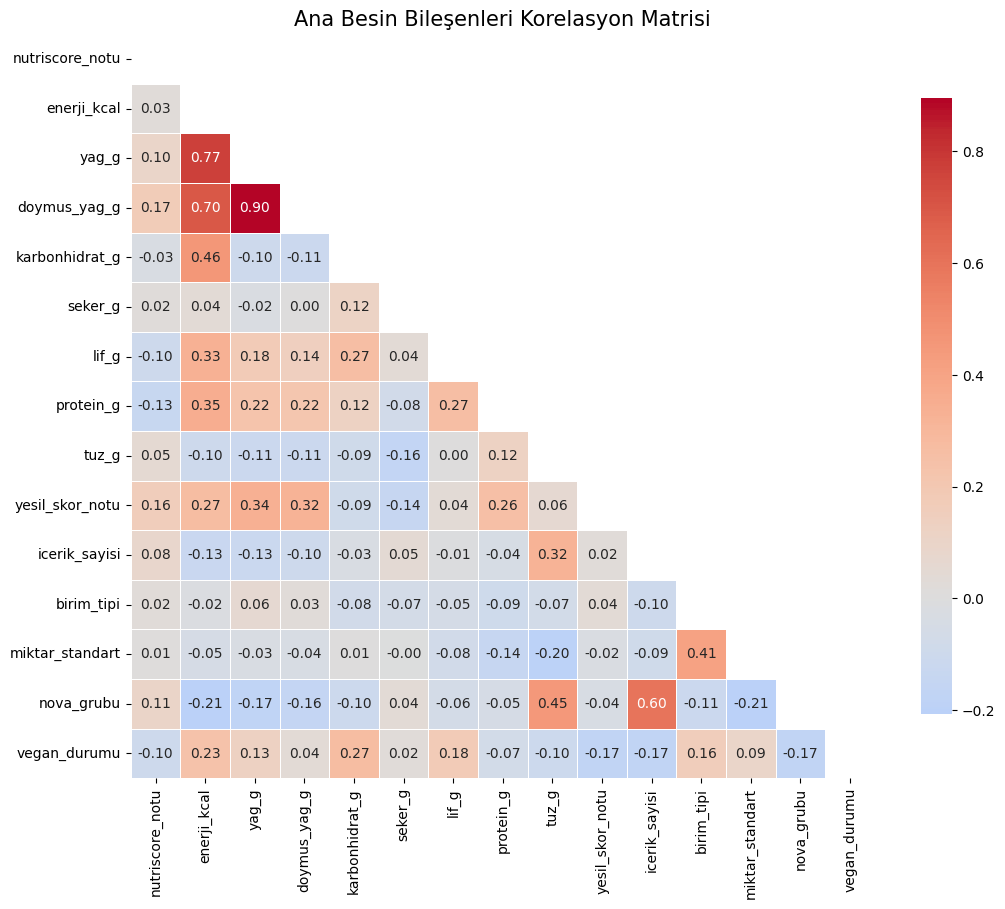

In [623]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sadece sayısal ve anlamlı ana sütunları seçelim 
# (Yüzlerce kategori sütununu matrise eklersek okunmaz hale gelir)
core_columns = [
    'nutriscore_notu', 'enerji_kcal', 'yag_g', 'doymus_yag_g', 
    'karbonhidrat_g', 'seker_g', 'lif_g', 'protein_g', 'tuz_g',
    'yesil_skor_notu', 'icerik_sayisi', 'birim_tipi', 'miktar_standart',
    'nova_grubu', 'vegan_durumu'
]

# Mevcut olanları filtrele
available_cols = [c for c in core_columns if c in data.columns]
corr_data = data[available_cols].corr()

# 2. Görselleştirme
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_data, dtype=bool)) # Üst üçgeni gizle (daha temiz görünür)

sns.heatmap(corr_data, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0,
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Ana Besin Bileşenleri Korelasyon Matrisi', fontsize=15)
plt.show()

In [624]:
data = data[~data['nutriscore_notu'].isin([2.0, 3.0, 4.0])]

In [ ]:
X = data.drop(columns=['nutriscore_notu', 'barkod'], errors='ignore')
y = data['nutriscore_notu']

In [626]:
y.value_counts()

nutriscore_notu
0.0    4403
1.0    1269
Name: count, dtype: int64

In [627]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [628]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    verbose=100,
    random_seed=42
)


model.fit(X_train, y_train, eval_set=(X_test, y_test))


y_pred = model.predict(X_test)

0:	learn: 0.6528311	test: 0.6523417	best: 0.6523417 (0)	total: 8.2ms	remaining: 4.09s
100:	learn: 0.2248487	test: 0.2389772	best: 0.2389772 (100)	total: 295ms	remaining: 1.16s
200:	learn: 0.1665324	test: 0.2022668	best: 0.2022668 (200)	total: 578ms	remaining: 860ms
300:	learn: 0.1351922	test: 0.1870460	best: 0.1870168 (292)	total: 861ms	remaining: 569ms
400:	learn: 0.1140097	test: 0.1796109	best: 0.1795894 (399)	total: 1.14s	remaining: 282ms
499:	learn: 0.0986147	test: 0.1755203	best: 0.1753975 (494)	total: 1.43s	remaining: 0us

bestTest = 0.1753974736
bestIteration = 494

Shrink model to first 495 iterations.


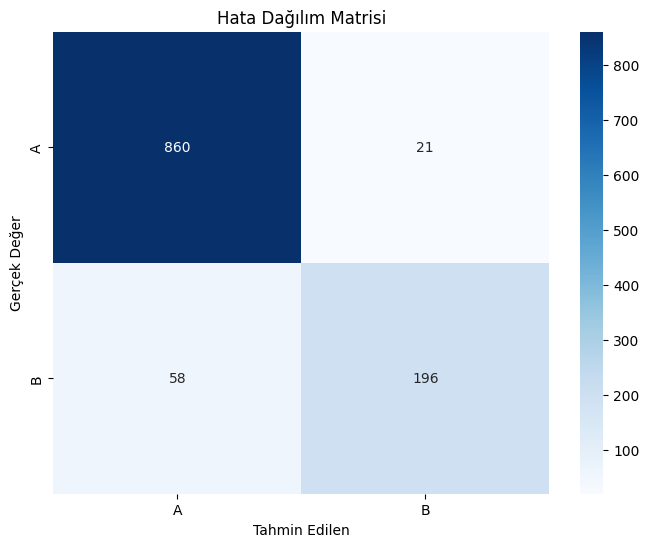

In [629]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['A', 'B'], 
            yticklabels=['A', 'B'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Hata Dağılım Matrisi')
plt.show()

In [630]:
print("\n--- CatBoost Model Performansı ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=['A', 'B']))

# 7. Özellik Önem Sıralaması (Hangi kolon etkili?)
feature_importance = model.get_feature_importance(type="FeatureImportance")
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance}).sort_values(by='Importance', ascending=False)

print("\nEn Etkili 10 Kolon:")
print(importance_df.head(10))


--- CatBoost Model Performansı ---
Accuracy: 0.9304

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           A       0.94      0.98      0.96       881
           B       0.90      0.77      0.83       254

    accuracy                           0.93      1135
   macro avg       0.92      0.87      0.89      1135
weighted avg       0.93      0.93      0.93      1135


En Etkili 10 Kolon:
                            Feature  Importance
13                        protein_g   13.381969
12                            lif_g   10.458008
14                            tuz_g    9.094918
9                      doymus_yag_g    6.780149
163  kategori_listesi_Spring_waters    5.356463
10                   karbonhidrat_g    4.825680
11                          seker_g    4.456508
7                       enerji_kcal    4.090517
8                             yag_g    2.551101
3                   yesil_skor_notu    2.545195
